# Precios de gafas graduadas — 2. Fusión, features y modelado del PVP

**Juan Antonio Muñoz Moreno** · agosto 2026

---

## Objetivo

El notebook 01 dejó dos cosas:

1. **Un hallazgo sobre el surtido:** el 90 % del catálogo de Óptica 2000 pertenece a su propietario o a su marca blanca, mientras General Óptica dedica más catálogo a su competidor (36,5 %) que a su propio grupo (27,6 %).
2. **Una observación sobre el precio:** en los 110 productos idénticos presentes en las dos tiendas, el **precio de catálogo coincide dentro de ±5 % en el 99 % de los casos**, pero el precio que paga el cliente difiere un 24 %.

Este notebook modela el **PVP** para responder una pregunta cuantitativa:

> **¿Cuánto del precio de una montura lo explica el producto y cuánto el nombre que lleva escrito?**

Y de paso pone a prueba la observación anterior: si el precio de catálogo está alineado entre cadenas, **la variable `tienda` no debería aportar nada al modelo**. Es una predicción falsable hecha antes de entrenar.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src" / "scraping"))
from marcas import asignar_grupo          # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
SEMILLA = 42

o2 = pd.read_csv(RAIZ / "data/raw/optica2000_graduadas.csv", dtype={"ean": str})
go = pd.read_csv(RAIZ / "data/raw/generaloptica_graduadas.csv", dtype={"ean": str})
go["ean"] = go["ean"].str.split(".").str[0]

# Las dos tiendas codifican la disponibilidad con nombre y formato distintos:
# `disponible` (booleano) en una, `disponibilidad` (URL de schema.org) en la otra.
# Al fusionar por intersección de columnas AMBAS se caían, y con ellas la
# información de stock. Se unifican aquí, antes de fusionar.
o2["en_stock"] = o2["disponible"].astype(bool)
go["en_stock"] = (go["disponibilidad"].str.split("/").str[-1]
                  .isin(["InStock", "InStoreOnly", "OnlineOnly"]))
print(f"Óptica 2000 {o2.shape} · General Óptica {go.shape}")

Óptica 2000 (1296, 26) · General Óptica (4825, 21)


---
## 1. Fusión de las dos tiendas

Las dos tiendas no publican los mismos campos. Óptica 2000 da forma y tipo de montura, ancho total y longitud de varilla; General Óptica no. Al fusionar hay que quedarse con la **intersección**.

**¿Cuánto cuesta esa pérdida?** Se midió antes de decidir la fuente de datos, sobre un dataset anterior: quedarse sin forma de montura, tipo de montura, longitud de varilla y talla costaba **0,09 € de MAE**. Está en el ruido. El calibre, el material y sobre todo la marca se llevan toda la señal, y esos sí están en las dos.

Merecía la pena comprobarlo en vez de suponerlo: la intuición decía que perder cuatro variables físicas sería caro, y la medición dijo que no.

In [2]:
comunes = sorted((set(o2.columns) & set(go.columns)) | {"en_stock"})
d = pd.concat([o2[comunes], go[comunes]], ignore_index=True)
d["grupo"] = asignar_grupo(d["marca"]).fillna("desconocido")
d = d[d["pvp"].notna()].reset_index(drop=True)

print(f"Columnas comunes ({len(comunes)}): {comunes}")
print(f"\nSolo en Óptica 2000  : {sorted(set(o2.columns) - set(go.columns))}")
print(f"Solo en General Óptica: {sorted(set(go.columns) - set(o2.columns))}")
print(f"\nDataset fusionado: {d.shape[0]} productos · {d['marca'].nunique()} marcas")
print(f"Reparto: {d['tienda'].value_counts().to_dict()}")
print(f"En stock: {d['en_stock'].sum()} de {len(d)} ({100*d['en_stock'].mean():.1f} %)")

Columnas comunes (19): ['ancho_lente', 'ancho_puente', 'color', 'descuento_pct', 'ean', 'en_oferta', 'en_stock', 'genero', 'marca', 'material_montura', 'mpn', 'nombre', 'precio_actual', 'precio_anterior', 'precio_solo_montura', 'pvp', 'tienda', 'ts_captura', 'url']

Solo en Óptica 2000  : ['ancho_montura', 'disponible', 'forma', 'largo_varilla', 'modelo', 'outlet', 'tipo_montura']
Solo en General Óptica: ['disponibilidad', 'sku']

Dataset fusionado: 6120 productos · 112 marcas
Reparto: {'generaloptica': 4825, 'optica2000': 1295}
En stock: 3071 de 6120 (50.2 %)


---
## 2. El split: por qué no puede ser aleatorio

**Aquí está la decisión metodológica que más importa de todo el notebook.**

Hay **110 productos idénticos** —mismo EAN, es decir mismo modelo, color y calibre— presentes en las dos tiendas. Con un split aleatorio, un Ray-Ban concreto podría caer en *train* por Óptica 2000 y su gemelo exacto en *test* por General Óptica.

El modelo habría visto ese producto durante el entrenamiento. Su error en test sería artificialmente bajo y la métrica, una mentira. Es fuga de datos de manual, y no la evita ningún `train_test_split(random_state=42)`.

La solución es agrupar por EAN: **todas las apariciones del mismo producto van juntas al mismo lado.** Se usa `GroupShuffleSplit`. Los productos sin EAN reciben un identificador único propio para que no se agrupen entre sí por error.

El split se hace **antes de cualquier imputación**, y los estadísticos de imputación se aprenden solo dentro del pipeline, es decir, solo con datos de entrenamiento.

In [3]:
# Clave de agrupación: el EAN. Los productos sin EAN reciben una clave única propia
# para que no acaben agrupados todos juntos.
sin_ean = pd.Series("sin-ean-" + d.index.astype(str), index=d.index)
d["clave_grupo"] = d["ean"].where(d["ean"].notna(), sin_ean)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
i_tr, i_te = next(gss.split(d, groups=d["clave_grupo"]))
TR, TE = d.iloc[i_tr].copy(), d.iloc[i_te].copy()

fuga = set(TR["clave_grupo"]) & set(TE["clave_grupo"])
print(f"train: {len(TR)} · test: {len(TE)}")
print(f"Productos (EAN) que aparecen en train Y en test: {len(fuga)}   <- debe ser 0")
print(f"\nPVP en train: mediana {TR['pvp'].median():.2f} € · test: {TE['pvp'].median():.2f} €")

train: 4902 · test: 1218
Productos (EAN) que aparecen en train Y en test: 0   <- debe ser 0

PVP en train: mediana 159.00 € · test: 153.99 €


---
## 3. Comparación de modelos

Se comparan cuatro enfoques, todos con el mismo preprocesado y el mismo split. **El `DummyRegressor` no está de adorno.** Predice siempre la media, y es la vara de medir de todo lo demás:

- Predecir siempre la media (175 €) se equivoca de media en **61,74 €**.
- El RandomForest se equivoca en **18,90 €**. Reduce el error un **70 %**.

**El R² es exactamente esa comparación**, expresada en error al cuadrado: `R² = 1 − (error del modelo / error de la media)²`. Por eso el Dummy sale en R² ≈ 0: es la definición de "no aportar nada".

Y por eso el R² **no dice si el problema era difícil**. Si todas las monturas costaran entre 100 y 110 €, la media ya acertaría casi siempre y un R² de 0,85 no tendría mérito. Aquí los precios van de 20 € a 846 €, la media falla por 62 € y batirla en un 70 % sí significa algo. El Dummy convierte esa idea abstracta en euros.

Los modelos lineales se entrenan sobre `log(PVP)` porque la distribución de precios está sesgada a la derecha, pero **se evalúan siempre en euros** para que las métricas sean comparables e interpretables.

In [4]:
NUM = ["ancho_lente", "ancho_puente"]
CAT = ["marca", "grupo", "tienda", "material_montura", "color", "genero"]

def preprocesador(num, cat, escalar=False):
    pasos_num = [("imp", SimpleImputer(strategy="median"))]
    if escalar:
        pasos_num.append(("sc", StandardScaler()))
    pipe_cat = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        [("n", Pipeline(pasos_num), num), ("c", pipe_cat, cat)], remainder="drop")

def evaluar(modelo, num, cat, etiqueta, escalar=False, log=False, target="pvp"):
    p = Pipeline([("prep", preprocesador(num, cat, escalar)), ("m", modelo)])
    if log:
        p = TransformedTargetRegressor(regressor=p, func=np.log1p, inverse_func=np.expm1)
    p.fit(TR[num + cat], TR[target])
    pred = p.predict(TE[num + cat])
    y = TE[target]
    return {
        "modelo": etiqueta,
        "MAE_€": mean_absolute_error(y, pred),
        "RMSE_€": np.sqrt(mean_squared_error(y, pred)),
        "R²": r2_score(y, pred),
        "MAPE_%": float(np.mean(np.abs((y - pred) / y)) * 100),
    }

RF = lambda: RandomForestRegressor(n_estimators=120, random_state=SEMILLA, n_jobs=-1)

resultados = [
    evaluar(DummyRegressor(strategy="mean"), NUM, CAT, "Dummy (media)"),
    evaluar(Ridge(alpha=1.0), NUM, CAT, "Ridge (sobre log)", escalar=True, log=True),
    evaluar(RF(), NUM, CAT, "RandomForest"),
    evaluar(HistGradientBoostingRegressor(random_state=SEMILLA), NUM, CAT, "HistGradientBoosting"),
]
pd.DataFrame(resultados).set_index("modelo").round(2)

,MAE_€,RMSE_€,R²,MAPE_%
modelo,,,,
Dummy (media),61.74,79.71,-0.00,46.52
Ridge (sobre log),19.71,31.23,0.85,11.33
RandomForest,18.93,30.85,0.85,10.66
HistGradientBoosting,22.77,36.75,0.79,13.42


El **RandomForest** gana, pero por poco margen sobre Ridge (18,9 € frente a 19,7 € de MAE). Eso ya dice algo: el problema tiene bastante estructura lineal una vez codificada la marca. El boosting queda claramente por detrás con los hiperparámetros por defecto.

Un MAPE del 10,6 % sobre una mediana de 158 € significa que el modelo se equivoca de media en torno a un 10 % del precio. Para fijar precios sería insuficiente; para entender qué explica el precio, sobra.

---
## 4. ¿Qué explica el precio? Ablaciones

Esta es la sección que responde la pregunta del proyecto. Se entrena el mismo modelo quitando y dejando bloques de variables. Cada fila es un modelo entrenado desde cero, no una permutación sobre un modelo ya ajustado.

In [5]:
ablaciones = [
    (NUM, CAT, "TODO"),
    ([], ["marca"], "solo marca"),
    (NUM, [], "solo geometría (calibre y puente)"),
    ([], ["grupo"], "solo grupo propietario"),
    ([], ["tienda"], "solo tienda"),
    (NUM, [c for c in CAT if c != "marca"], "todo menos marca"),
    (NUM, [c for c in CAT if c != "tienda"], "todo menos tienda"),
    (NUM, [c for c in CAT if c not in ("marca", "grupo")], "sin marca ni grupo"),
]
abl = pd.DataFrame([evaluar(RF(), n, c, lab) for n, c, lab in ablaciones]).set_index("modelo")
abl.round(2)

,MAE_€,RMSE_€,R²,MAPE_%
modelo,,,,
TODO,18.93,30.85,0.85,10.66
solo marca,21.07,34.26,0.81,12.12
solo geometría (calibre y puente),54.00,72.84,0.16,38.09
solo grupo propietario,50.72,69.48,0.24,35.17
solo tienda,61.75,79.60,-0.00,46.28
todo menos marca,41.36,62.39,0.39,25.39
todo menos tienda,19.13,31.21,0.85,10.84
sin marca ni grupo,53.06,74.09,0.13,35.77


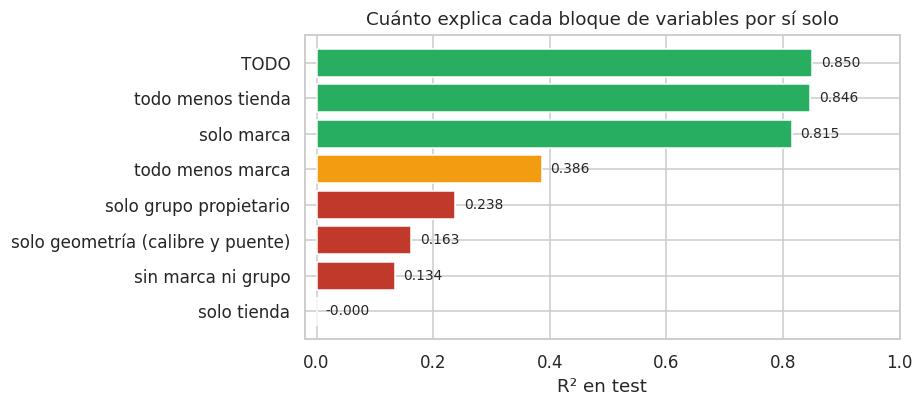

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
o = abl["R²"].sort_values()
col = ["#c0392b" if v < .3 else "#f39c12" if v < .7 else "#27ae60" for v in o]
ax.barh(o.index, o.values, color=col)
ax.set_xlabel("R² en test"); ax.set_xlim(-0.02, 1)
ax.set_title("Cuánto explica cada bloque de variables por sí solo")
for i, v in enumerate(o.values):
    ax.text(max(v, 0) + .015, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

### Lo que dicen las ablaciones

| Con solo… | R² |
|---|---:|
| **la marca** | **0,81** |
| la geometría (calibre y puente) | 0,16 |
| el grupo propietario | 0,24 |
| **la tienda** | **0,00** |

**El nombre escrito en la patilla explica el 81 % de la varianza del precio. La geometría de la montura, el 16 %.**

Es la respuesta a la pregunta del proyecto, y es contundente: dos monturas del mismo calibre, mismo material y mismo color pueden separarse cientos de euros según la marca. La marca no es una variable más del modelo: es *casi todo* el modelo.

Coherente con ello, **quitar la marca destruye el modelo** (R² 0,850 → 0,387) mientras que quitar la tienda no lo mueve (0,850 → 0,848).

**El grupo propietario solo da 0,24, muy por debajo de la marca (0,81).** Tiene sentido: el grupo es una agrupación gruesa de la marca. Saber que una montura es de EssilorLuxottica dice bastante menos que saber que es una Ray-Ban, porque el mismo grupo licencia desde Arnette hasta Chanel. Es útil como variable estructural para el análisis, no como predictor.

### La predicción del notebook 01 se cumple

`tienda` sola da **R² = 0,000**: no explica absolutamente nada del precio de catálogo. Y quitarla del modelo completo cuesta 0,15 € de MAE.

Eso confirma con 6.120 productos lo que se había observado con los 110 de EAN común: **el precio de catálogo de una montura es el mismo la venda quien la venda.** Es una predicción hecha en el notebook anterior y verificada aquí por una vía independiente.

---
## 5. El contraste: PVP frente a precio pagado

Si la tienda no importa para el precio de catálogo, ¿importa para lo que paga el cliente? Mismo modelo, mismas variables, distinto objetivo.

In [7]:
filas = []
for target in ["pvp", "precio_actual"]:
    for cat, lab in [(CAT, "con tienda"), ([c for c in CAT if c != "tienda"], "SIN tienda")]:
        r = evaluar(RF(), NUM, cat, lab, target=target)
        r["target"] = target
        filas.append(r)
comp = pd.DataFrame(filas).set_index(["target", "modelo"])[["MAE_€", "R²"]].round(3)
comp

MAE_€     R²
target        modelo                   
pvp           con tienda  18.928  0.850
              SIN tienda  19.133  0.846
precio_actual con tienda  23.104  0.725
              SIN tienda  23.618  0.705

Predecir el **precio pagado** es claramente más difícil que predecir el **PVP**: el R² cae de 0,85 a 0,72 y el MAE sube de 18,9 € a 23,2 €.

La diferencia no es ruido de medición: es la **capa promocional**. El precio del día incorpora una decisión comercial —qué campaña hay activa esa semana— que no está codificada en ninguna característica del producto. El modelo no puede aprenderla porque la información no está en los datos.

Ese es el argumento cuantitativo para haber elegido el PVP como objetivo: **modelar el precio actual sería modelar, en parte, el calendario de marketing de una cadena.** Y ese calendario cambia cada semana, así que el modelo caducaría solo.

---
## 6. Importancia de variables, con su matiz

La *permutation importance* mide cuánto empeora **este modelo ya entrenado** al desordenar una columna. **No mide cuánta información aporta la variable al problema.**

La distinción importa y se ve comparando esta sección con las ablaciones: si dos variables están correlacionadas —como `marca` y `grupo`, donde una es agrupación de la otra— la permutación reparte el mérito entre ambas, mientras que reentrenar sin una de ellas muestra que la otra la sustituye casi por completo.

Las ablaciones son la prueba fuerte. Esto es un complemento.

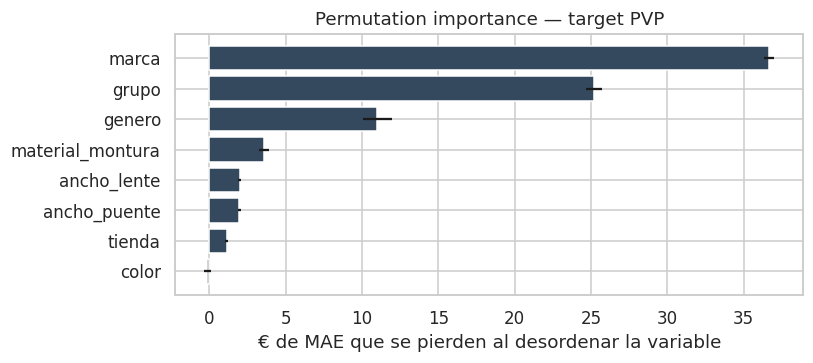

,variable,MAE_extra_€,sd
0,marca,36.66,0.35
1,grupo,25.20,0.54
2,genero,11.01,0.94
3,material_montura,3.57,0.32
4,ancho_lente,2.00,0.08
5,ancho_puente,1.96,0.10
6,tienda,1.14,0.08
7,color,-0.12,0.23


In [8]:
final = Pipeline([("prep", preprocesador(NUM, CAT)), ("m", RF())])
final.fit(TR[NUM + CAT], TR["pvp"])

perm = permutation_importance(final, TE[NUM + CAT], TE["pvp"], n_repeats=3,
                              random_state=SEMILLA, n_jobs=-1,
                              scoring="neg_mean_absolute_error")
imp = (pd.DataFrame({"variable": NUM + CAT,
                     "MAE_extra_€": perm.importances_mean,
                     "sd": perm.importances_std})
       .sort_values("MAE_extra_€", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(imp["variable"][::-1], imp["MAE_extra_€"][::-1],
        xerr=imp["sd"][::-1], color="#34495e")
ax.set_xlabel("€ de MAE que se pierden al desordenar la variable")
ax.set_title("Permutation importance — target PVP")
plt.tight_layout(); plt.show()
imp.round(2)

---
## 7. Dónde falla el modelo

Un modelo se entiende mejor por sus errores que por su métrica global.

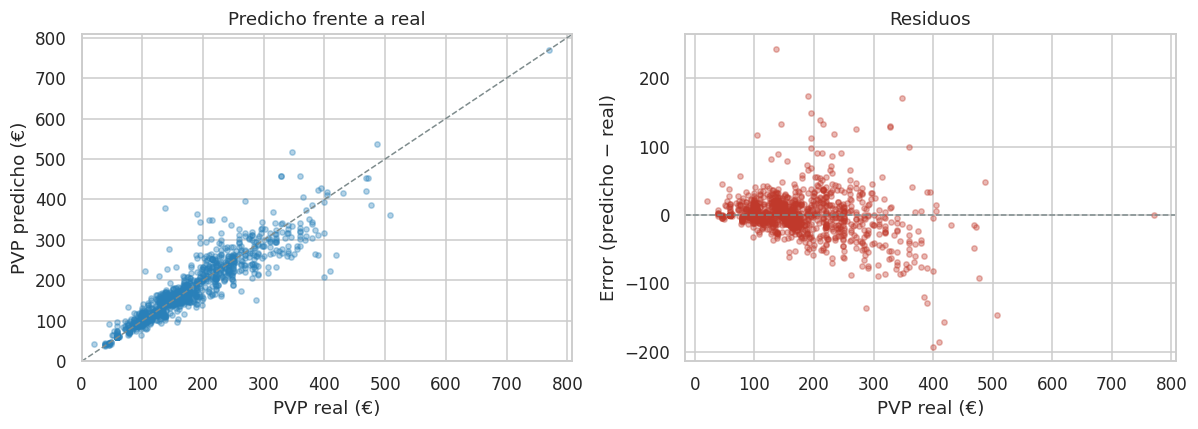

             n    MAE  error_medio  MAPE
pvp                                     
<100 €     211   8.02         5.05     0
100-150 €  375  13.07         6.01     0
150-200 €  287  17.01        -0.68     0
200-300 €  258  27.85         0.43     0
>300 €      87  50.54       -30.84     0

MAPE por tramo:
pvp
<100 €       10.4
100-150 €    10.2
150-200 €     9.7
200-300 €    11.5
>300 €       13.9


In [9]:
TE = TE.copy()
TE["pred"] = final.predict(TE[NUM + CAT])
TE["error"] = TE["pred"] - TE["pvp"]
TE["error_abs"] = TE["error"].abs()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
lim = [0, TE["pvp"].max() * 1.05]
ax[0].plot(lim, lim, "--", color="#7f8c8d", lw=1)
ax[0].scatter(TE["pvp"], TE["pred"], s=12, alpha=.35, color="#2980b9")
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("PVP real (€)"); ax[0].set_ylabel("PVP predicho (€)")
ax[0].set_title("Predicho frente a real")

ax[1].axhline(0, color="#7f8c8d", lw=1, ls="--")
ax[1].scatter(TE["pvp"], TE["error"], s=12, alpha=.35, color="#c0392b")
ax[1].set_xlabel("PVP real (€)"); ax[1].set_ylabel("Error (predicho − real)")
ax[1].set_title("Residuos")
plt.tight_layout(); plt.show()

tramos = pd.cut(TE["pvp"], [0, 100, 150, 200, 300, 10000],
                labels=["<100 €", "100-150 €", "150-200 €", "200-300 €", ">300 €"])
print(TE.groupby(tramos).agg(n=("pvp", "size"), MAE=("error_abs", "mean"),
                             error_medio=("error", "mean"),
                             MAPE=("pvp", lambda s: 0)).round(2).to_string())
print("\nMAPE por tramo:")
print(TE.groupby(tramos).apply(lambda g: 100*(g['error_abs']/g['pvp']).mean()).round(1).to_string())

El patrón de residuos es el clásico de un modelo de árboles sobre precios: **infraestima los productos caros y sobreestima los baratos**, porque un bosque no puede predecir fuera del rango de los valores que vio en las hojas. Los productos por encima de 300 € son pocos y muy heterogéneos, así que el error relativo crece ahí.

Para el uso que se le da a este modelo —cuantificar qué explica el precio— ese sesgo no invalida nada. Si se quisiera usar para fijar precios de gama alta, habría que tratarlo: más datos en ese tramo, o un modelo sobre el logaritmo.

In [10]:
peores = TE.nlargest(10, "error_abs")[["tienda", "marca", "grupo", "nombre", "pvp", "pred", "error"]]
peores["nombre"] = peores["nombre"].str.slice(0, 42)
print("Los 10 productos donde más se equivoca:")
peores.round(1)

Los 10 productos donde más se equivoca:


,tienda,marca,grupo,nombre,pvp,pred,error
913,optica2000,Ray-Ban,EssilorLuxottica,Ray-Ban RB7257 8260,137.0,379.8,242.8
2343,generaloptica,Ermenegildo Zegna,Marcolin,Gafas graduadas Ermenegildo Zegna EZ5348 N,400.0,207.9,-192.1
2471,generaloptica,Eschenbach,Independiente,Gafas graduadas Eschenbach 821038 Dorados,409.9,224.3,-185.6
5859,generaloptica,Vuillet Vega,Independiente,Gafas graduadas Vuillet Vega PRIMA LINEA 5,190.0,364.0,174.0
458,optica2000,Giorgio Armani,EssilorLuxottica,Giorgio Armani 0AR7248 5988,347.0,518.5,171.5
1554,generaloptica,Carolina Herrera New York,Safilo,Gafas graduadas Carolina Herrera New York,419.0,262.6,-156.4
5989,generaloptica,Yves Saint Laurent,Kering Eyewear,Gafas graduadas Yves Saint Laurent SL 504,195.0,345.0,150.0
4331,generaloptica,Porsche Design,De Rigo,Gafas graduadas Porsche Design P8764 Plate,508.0,361.8,-146.2
5998,generaloptica,Yves Saint Laurent,Kering Eyewear,Gafas graduadas Yves Saint Laurent SL 643,210.0,348.4,138.4
3778,generaloptica,Oakley,EssilorLuxottica,Gafas graduadas Oakley TIE BAR 0.5 0OX5140,287.0,150.8,-136.2


---
## 8. Comprobación de robustez: los productos agotados

El 63 % del catálogo de General Óptica está **agotado** pero mantiene precio publicado. Un precio de un producto descatalogado puede estar sin actualizar, así que cabe la duda de si esos 3.049 productos están ensuciando el modelo.

**`en_stock` no se usa como variable del modelo, y es deliberado.** Está construida de forma distinta en cada tienda: en Óptica 2000 el scraper descarta los no disponibles al rastrear, así que sale `True` casi siempre por construcción; en General Óptica se captura tal cual. Metida como feature estaría codificando en parte *de qué tienda viene el producto*, disfrazada de disponibilidad. Es un confusor introducido por el propio método de captura.

Lo que sí se puede hacer es **reentrenar solo con producto disponible y comparar**.

In [11]:
d_stock = d[d["en_stock"]].reset_index(drop=True)

def entrenar_en(df, num, cat, etiqueta):
    se = pd.Series("x" + df.index.astype(str), index=df.index)
    grupos = df["ean"].where(df["ean"].notna(), se)
    itr, ite = next(GroupShuffleSplit(n_splits=1, test_size=.2,
                                      random_state=SEMILLA).split(df, groups=grupos))
    tr, te = df.iloc[itr], df.iloc[ite]
    p = Pipeline([("prep", preprocesador(num, cat)), ("m", RF())])
    p.fit(tr[num + cat], tr["pvp"]); pred = p.predict(te[num + cat])
    dummy = DummyRegressor().fit(tr[num + cat], tr["pvp"]).predict(te[num + cat])
    return {"escenario": etiqueta, "n": len(df),
            "MAE_€": mean_absolute_error(te["pvp"], pred),
            "R²": r2_score(te["pvp"], pred),
            "MAE_dummy_€": mean_absolute_error(te["pvp"], dummy)}

filas = []
for df_, lab in [(d, "todos"), (d_stock, "solo en stock")]:
    filas.append({**entrenar_en(df_, NUM, CAT, f"modelo completo · {lab}")})
    filas.append({**entrenar_en(df_, [], ["marca"], f"solo marca · {lab}")})
    filas.append({**entrenar_en(df_, NUM, [], f"solo geometría · {lab}")})
    filas.append({**entrenar_en(df_, [], ["tienda"], f"solo tienda · {lab}")})
pd.DataFrame(filas).set_index("escenario").round(3)

,n,MAE_€,R²,MAE_dummy_€
escenario,,,,
modelo completo · todos,6120,18.928,0.850,61.739
solo marca · todos,6120,21.072,0.815,61.739
solo geometría · todos,6120,53.997,0.163,61.739
solo tienda · todos,6120,61.749,-0.000,61.739
modelo completo · solo en stock,3071,18.653,0.911,72.428
solo marca · solo en stock,3071,21.086,0.868,72.428
solo geometría · solo en stock,3071,63.858,0.171,72.428
solo tienda · solo en stock,3071,71.823,0.013,72.428


**Las conclusiones no se mueven.** El modelo completo pasa de 18,90 € a 18,66 € de MAE: prácticamente idéntico. Las ablaciones mantienen el mismo orden y las mismas magnitudes: la marca lo explica casi todo, la geometría poco, la tienda nada.

**Los precios de los productos agotados no estaban envenenando el modelo.** Se conserva el dataset completo.

Y hay aquí una lección sobre el R² que merece la pena señalar, porque es contraintuitiva:

> El R² **sube** de 0,850 a 0,911 al quedarse solo con el producto en stock, pero el modelo **no ha mejorado**: el MAE es el mismo. Lo que cambia es el baseline — el subconjunto en stock tiene más dispersión de precios, así que predecir la media falla más (72,4 € en vez de 61,7 €) y explicarla luce mejor.

Un R² más alto sobre un subconjunto distinto **no es un modelo mejor**. Es otro examen. Comparar R² entre datasets distintos sin mirar el baseline es una de las formas más fáciles de engañarse.

---
## 9. Limitaciones

1. **Comercio online.** En España la venta online supone en torno al 10 % del mercado de gafas graduadas. Estos precios son de catálogo web de dos cadenas concretas, no del mercado español.
2. **Una foto de agosto de 2026.** Los precios de catálogo son estables, pero no eternos.
3. **Sesgo en la cola alta.** El modelo infraestima por encima de 300 €, donde hay pocos datos.
4. **Faltan variables físicas** que sí existían en otra fuente: peso, forma, tipo de montura y longitud de varilla. Se midió que su aportación conjunta era marginal (0,09 € de MAE), pero conviene declararlo.
5. **El 63 % del catálogo de General Óptica está agotado** aunque mantenga precio publicado. Se comprobó que excluirlos no cambia ninguna conclusión (sección 8), pero conviene saber que la mitad del dataset son productos que hoy no se pueden comprar.
6. **`grupo` está a "desconocido" en 16 productos** (0,26 %) cuya marca no se pudo clasificar. No se eliminaron: borrar filas por una variable ausente sesgaría la muestra.
7. **Correlación, no causalidad.** El modelo mide asociación entre marca y precio. No demuestra que la marca *cause* el precio; ambos podrían responder a un posicionamiento comercial anterior que estos datos no observan.
8. **No se ha optimizado hiperparámetros.** Los modelos usan valores por defecto salvo el número de árboles. Un `GridSearchCV` mejoraría algunas décimas, pero la conclusión —qué variables explican el precio— no depende de eso.

---
## 10. Conclusiones

1. **El modelo funciona:** RandomForest con MAE de 18,9 €, R² de 0,850 y MAPE del 10,6 %, frente a un baseline de 61,7 € de MAE. Sobre una mediana de 158 €.
2. **La marca explica el 81 % de la varianza del precio; la geometría de la montura, el 16 %.** Dos monturas físicamente equivalentes pueden separarse cientos de euros por el nombre que llevan.
3. **La tienda no explica nada del precio de catálogo (R² = 0,000).** Confirma con 6.120 productos la observación que el notebook 01 hizo con 110: el precio de catálogo de una montura no depende de quién la venda.
4. **Predecir el precio pagado es más difícil que predecir el PVP** (R² 0,72 frente a 0,85), porque el precio del día incorpora una decisión de campaña que no está en los datos del producto.
5. **El resultado es robusto al stock.** Reentrenar solo con producto disponible deja el MAE en 18,66 € y mantiene todas las ablaciones. Los precios de los productos agotados no distorsionan el modelo.

**Uniendo los dos notebooks:** la propiedad del minorista determina **qué** puedes comprar —el 90 % del catálogo de Óptica 2000 es de su dueño— pero no **a cuánto**: el precio de catálogo está alineado entre cadenas y lo fija la marca, no la tienda. La competencia entre estas dos cadenas no ocurre en el precio nominal, sino en el surtido y en la política de descuento.